# APRENDIZAJE AUTOMÁTICO
# Práctica 3: Regresión Logística Binaria
### Autor: Sanchez Sarsa, Eduardo
### NIP:   901813
### Fecha: 20-02-2026
---


## Configuración


In [1]:
%matplotlib inline
# try:
#   from google.colab import drive
#   print("Trabajando en Colab")
#   drive.mount('/content/drive')                # Monta tu google drive
#   Path = '/content/drive/MyDrive/Aprendizaje/' # Directorio donde guardas los ficheros
# except:
print("Trabajando en local")
import os
Path = os.getcwd() + "/"  # Directorio donde guardas los ficheros


Trabajando en local


---
## 0. Visualización de datos


Train: 142 muestras | positivos=45 (0.317)
Test : 36 muestras | positivos=14 (0.389)


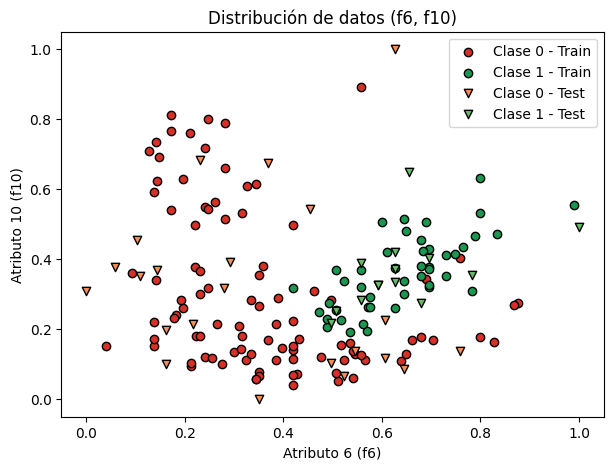

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.exceptions import ConvergenceWarning
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

warnings.filterwarnings("ignore", category=ConvergenceWarning)
SEED = 28


# Dibuja la frontera y los puntos de train/test para clasificadores binarios con 2 atributos.
def dibujar_clasificador(clf, X_train, y_train, X_test, y_test, titulo):
    colores = ListedColormap(["#d73027", "#1a9850"])
    fig, ax = plt.subplots(figsize=(7, 5))
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X_train,
        eps=0.15,
        cmap=colores,
        grid_resolution=400,
        response_method="predict",
        alpha=0.30,
        ax=ax,
    )
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c="#d73027", edgecolors="k", label="0 - Train")
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c="#1a9850", edgecolors="k", label="1 - Train")
    ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c="#d73027", marker="v", edgecolors="k", label="0 - Test")
    ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c="#1a9850", marker="v", edgecolors="k", label="1 - Test")
    ax.set_xlabel("Atributo 6 (f6)")
    ax.set_ylabel("Atributo 10 (f10)")
    ax.set_title(titulo)
    ax.legend(loc="best")
    plt.show()


# Leer los ficheros de datos y pasarlos a matrices de numpy.
data_train = pd.read_csv(Path + "wine_train.csv", sep=";")
data_test = pd.read_csv(Path + "wine_test.csv", sep=";")

X_train = data_train[["f6", "f10"]].to_numpy()
X_test = data_test[["f6", "f10"]].to_numpy()
y_train = (data_train["Clase"].to_numpy() == 1).astype(int)
y_test = (data_test["Clase"].to_numpy() == 1).astype(int)

print(f"Train: {X_train.shape[0]} muestras | positivos={y_train.sum()} ({y_train.mean():.3f})")
print(f"Test : {X_test.shape[0]} muestras | positivos={y_test.sum()} ({y_test.mean():.3f})")

plt.figure(figsize=(7, 5))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c="#d73027", edgecolors="k", label="Clase 0 - Train")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c="#1a9850", edgecolors="k", label="Clase 1 - Train")
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c="#fc8d59", marker="v", edgecolors="k", label="Clase 0 - Test")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c="#66bd63", marker="v", edgecolors="k", label="Clase 1 - Test")
plt.title("Distribución de datos (f6, f10)")
plt.xlabel("Atributo 6 (f6)")
plt.ylabel("Atributo 10 (f10)")
plt.legend(loc="best")
plt.show()


Los datos están normalizados y hay cierto desbalance de clase (la clase 1 es minoritaria en entrenamiento), por lo que no conviene fijarse solo en `accuracy`. Además, en el plano `(f6, f10)` se aprecia solapamiento entre clases, lo que hace útil comparar un modelo lineal frente a uno no lineal y regularizado.


---
## 1. Métricas

Para este problema de detección de clase 1, son especialmente relevantes:

- `precision`: evita falsos positivos si queremos que las predicciones de clase 1 sean fiables.
- `recall`: mide cuántos vinos de clase 1 conseguimos detectar.
- `F1`: equilibrio entre `precision` y `recall`.
- `average precision (AP)` y curvas `precision/recall`: útiles con clases desbalanceadas y para comparar umbrales.
- `ROC-AUC`: complementa la evaluación basada en ranking de probabilidades.

Se mantiene `f1` como referencia, pero no como métrica principal.


In [3]:
# Las gráficas han sido generadas con inteligencia artficial.

def metricas_binarias(y_true, y_pred, y_prob):
    metricas = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if len(np.unique(y_true)) == 2:
        metricas["roc_auc"] = roc_auc_score(y_true, y_prob)
        metricas["average_precision"] = average_precision_score(y_true, y_prob)
    else:
        metricas["roc_auc"] = np.nan
        metricas["average_precision"] = np.nan

    return metricas


def evaluar_modelo(modelo, nombre, X_train, y_train, X_test, y_test, umbral=None):
    filas = []

    for split, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        y_prob = modelo.predict_proba(X)[:, 1]
        if umbral is None:
            y_pred = modelo.predict(X)
            umbral_usado = np.nan
        else:
            y_pred = (y_prob >= umbral).astype(int)
            umbral_usado = umbral
        m = metricas_binarias(y, y_pred, y_prob)
        tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()
        m.update({
            "modelo": nombre,
            "split": split,
            "umbral": umbral_usado,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        })
        filas.append(m)

    columnas = [
        "modelo", "split", "accuracy", "precision", "recall", "f1",
        "average_precision", "roc_auc", "umbral", "tn", "fp", "fn", "tp"
    ]
    return pd.DataFrame(filas)[columnas]


def dibujar_roc_train_test(modelo, nombre, X_train, y_train, X_test, y_test):
    fig, ax = plt.subplots(figsize=(7, 5))

    for split, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        y_prob = modelo.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_prob)
        auc = roc_auc_score(y, y_prob)
        ax.plot(fpr, tpr, linewidth=2, label=f"{split} | AUC={auc:.3f}")

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Tasa de Falsos Positivos")
    ax.set_ylabel("Tasa de Verdaderos Positivos")
    ax.set_title(f"ROC - {nombre}")
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")
    plt.show()


print("Métrica principal para selección: f1_score (f1)")
print(f"Prevalencia de clase 1 en train: {y_train.mean():.3f}")
print(f"Prevalencia de clase 1 en test : {y_test.mean():.3f}")


Métrica principal para selección: f1_score (f1)
Prevalencia de clase 1 en train: 0.317
Prevalencia de clase 1 en test : 0.389


---
## 2. Regresión logística básica
### a) Entrenamiento, superficie de separación y evaluación


c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


,modelo,split,accuracy,precision,recall,f1,average_precision,roc_auc,umbral,tn,fp,fn,tp
0,Logística básica,train,0.809859,0.736842,0.622222,0.674699,0.744699,0.906758,NaN,87,10,17,28
1,Logística básica,test,0.861111,0.846154,0.785714,0.814815,0.771994,0.883117,NaN,20,2,3,11


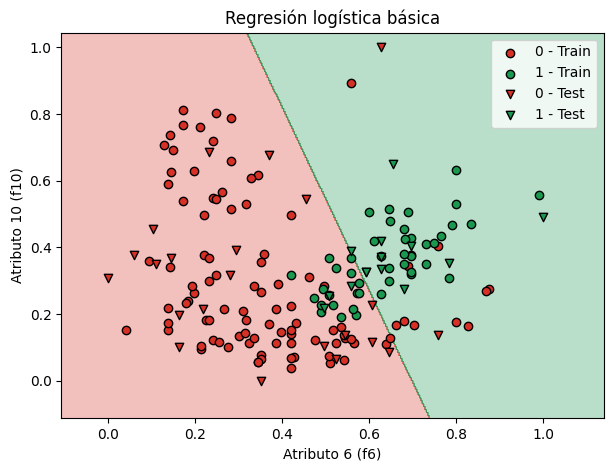

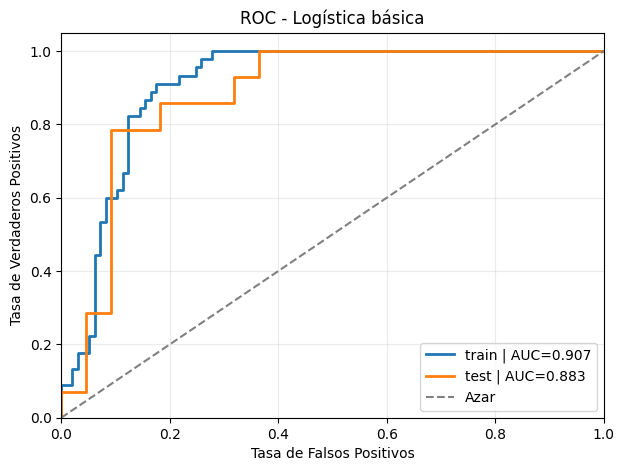

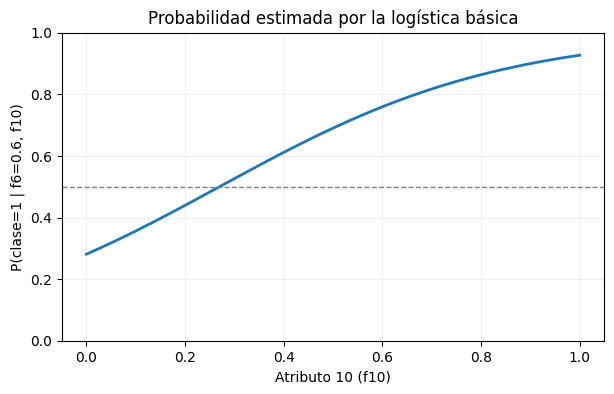

Coeficientes: w_f6=9.5578, w_f10=3.4811, b=-6.6739
Para f6=0.6, el punto con P=0.5 ocurre en f10≈0.2698


In [4]:
logit_basico = LogisticRegression(l1_ratio=0, C=np.inf, tol=1e-6)
logit_basico.fit(X_train, y_train)

metricas_basico = evaluar_modelo(
    logit_basico,
    "Logística básica",
    X_train,
    y_train,
    X_test,
    y_test
)

display(metricas_basico)
dibujar_clasificador(logit_basico, X_train, y_train, X_test, y_test, "Regresión logística básica")

dibujar_roc_train_test(logit_basico, "Logística básica", X_train, y_train, X_test, y_test)



# Las gráficas han sido generadas con inteligencia artficial.
# Probabilidad para f6=0.6 y f10 entre 0 y 1.
f10_grid = np.linspace(0.0, 1.0, 100)
X_consulta = np.c_[np.full_like(f10_grid, 0.6), f10_grid]
prob_clase1 = logit_basico.predict_proba(X_consulta)[:, 1]

plt.figure(figsize=(7, 4))
plt.plot(f10_grid, prob_clase1, color="#1f78b4", linewidth=2)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Atributo 10 (f10)")
plt.ylabel("P(clase=1 | f6=0.6, f10)")
plt.title("Probabilidad estimada por la logística básica")
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.show()

w_f6, w_f10 = logit_basico.coef_[0]
b = logit_basico.intercept_[0]
print(f"Coeficientes: w_f6={w_f6:.4f}, w_f10={w_f10:.4f}, b={b:.4f}")

if abs(w_f10) > 1e-12:
    f10_corte = -(b + w_f6 * 0.6) / w_f10
    print(f"Para f6=0.6, el punto con P=0.5 ocurre en f10≈{f10_corte:.4f}")
else:
    print("w_f10≈0: la probabilidad casi no depende de f10")


## Explicación
En la gráfica vemos representado en el Eje Y la probabilidad de que el vino sea de la clase 1 con el parámetro f6 fijado a 0.6
y en el eje X vemos el valor del atributo 10, al dibujar la linea horizontal en Y = 0.5, partimos la gráfica en 2, la mitad inferior serían valores de f10 y f6 = 0.6 que no se aceptan como clase 1, y en la parte superior veríamos valores que se aceptan como clase 1.

Es una curva perteneciente a una función sigmoidal, que veríamos si ajustamos los valores de X iniciales y finales.

---
## 3. Expansión polinómica (grado 6) sin regularizar


Solver seleccionado para el modelo sin regularizar: sag (CV F1=0.8745)


,modelo,split,accuracy,precision,recall,f1,average_precision,roc_auc,umbral,tn,fp,fn,tp
0,Polinómica g6 sin regularizar (sag),train,0.950704,0.913043,0.933333,0.923077,0.953549,0.983276,NaN,93,4,3,42
1,Polinómica g6 sin regularizar (sag),test,0.916667,0.923077,0.857143,0.888889,0.976798,0.983766,NaN,21,1,2,12


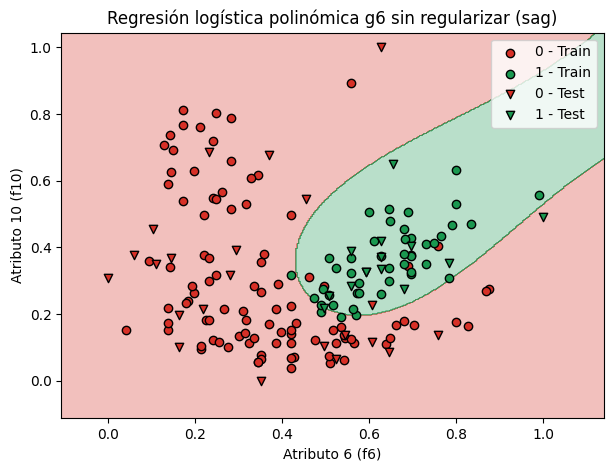

In [5]:
solvers_sin_reg = ["lbfgs", "newton-cg", "saga", "sag", "newton-cholesky"]  # "liblinear" no soporta penalty=None
cv = KFold(n_splits=5, shuffle=True, random_state=28)
warnings.filterwarnings("ignore", category=UserWarning, message="Setting penalty=None")

grid_sin_reg = GridSearchCV(
    estimator=Pipeline(
        [
            ("poly", PolynomialFeatures(degree=6)),
            ("logreg", LogisticRegression(C=np.inf, max_iter=1000, tol=1e-8)),
        ]
    ),
    param_grid={"logreg__solver": solvers_sin_reg},
    scoring={"ap": "average_precision", "f1": "f1"},
    cv=cv,
    refit="f1",
    return_train_score=True,
    n_jobs=-1,
)

grid_sin_reg.fit(X_train, y_train)
cv_results_sin_reg = grid_sin_reg.cv_results_
df_sin_reg = pd.DataFrame(
    {
        "solver": np.array(cv_results_sin_reg["param_logreg__solver"], dtype=str),
        "ap_train_media": cv_results_sin_reg["mean_train_ap"],
        "ap_val_media": cv_results_sin_reg["mean_test_ap"],
        "f1_train": cv_results_sin_reg["mean_train_f1"],
        "f1_val": cv_results_sin_reg["mean_test_f1"],
    }
).sort_values(by="f1_val", ascending=False)
mejor_solver_sin_reg = grid_sin_reg.best_params_["logreg__solver"]
modelo_poly_sin_reg = grid_sin_reg.best_estimator_

print(
    f"Solver seleccionado para el modelo sin regularizar: {mejor_solver_sin_reg} "
    f"(CV F1={grid_sin_reg.best_score_:.4f})",
    flush=True
)

metricas_sin_reg = evaluar_modelo(
    modelo_poly_sin_reg,
    f"Polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
    X_train,
    y_train,
    X_test,
    y_test
)
display(metricas_sin_reg)

dibujar_clasificador(
    modelo_poly_sin_reg,
    X_train,
    y_train,
    X_test,
    y_test,
    f"Regresión logística polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
)

c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:591: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengths.
The original Linear Algebra message was:
Ill-conditioned matrix (rcond=4.11357e-25): result may not be accurate.
  warnings.warn(


,solver,ap_train_media,ap_val_media,f1_train,f1_val
4,newton-cholesky,0.990674,0.868219,0.954012,0.885608
1,newton-cg,1.000000,0.850924,1.000000,0.884474
3,sag,0.954150,0.933243,0.917194,0.884180
0,lbfgs,0.990202,0.821657,0.951420,0.877857
2,saga,0.952111,0.935987,0.879818,0.859412


c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:591: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengths.
The original Linear Algebra message was:
Ill-conditioned matrix (rcond=4.11357e-25): result may not be accurate.
  warnings.warn(


Solver seleccionado para el modelo sin regularizar: newton-cholesky (CV F1=0.8856)


,modelo,split,accuracy,precision,recall,f1,average_precision,roc_auc,umbral,tn,fp,fn,tp
0,Polinómica g6 sin regularizar (newton-cholesky),train,0.964789,0.916667,0.977778,0.946237,0.984341,0.993585,NaN,93,4,1,44
1,Polinómica g6 sin regularizar (newton-cholesky),test,0.888889,0.916667,0.785714,0.846154,0.785568,0.892857,NaN,21,1,3,11


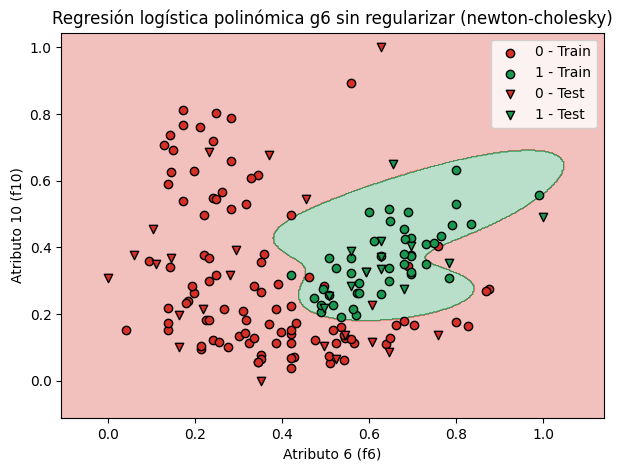

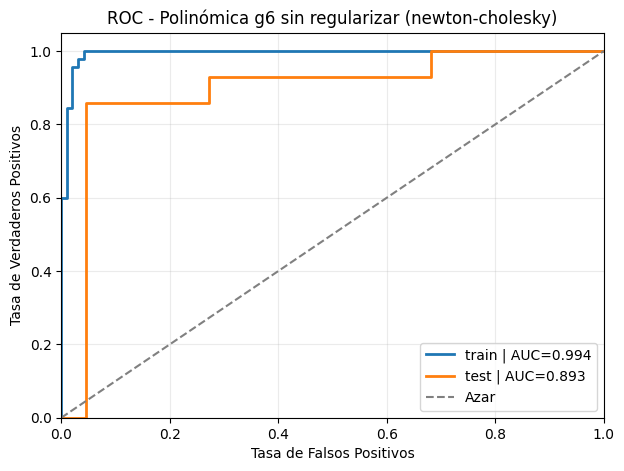

In [6]:
solvers_sin_reg = ["lbfgs", "newton-cg", "saga", "sag", "newton-cholesky"]  # "liblinear" no soporta penalty=None
# cv = KFold(n_splits=5, shuffle=True, random_state=28)
warnings.filterwarnings("ignore", category=UserWarning, message="Setting penalty=None")

grid_sin_reg = GridSearchCV(
    estimator=Pipeline(
        [
            ("poly", PolynomialFeatures(degree=6)),
            ("logreg", LogisticRegression(C=np.inf, max_iter=1000, tol=1e-8)),
        ]
    ),
    param_grid={"logreg__solver": solvers_sin_reg},
    scoring={"ap": "average_precision", "f1": "f1"},
    # cv=cv,
    refit="f1",
    return_train_score=True,
    n_jobs=-1,
)

grid_sin_reg.fit(X_train, y_train)

cv_results_sin_reg = grid_sin_reg.cv_results_
df_sin_reg = pd.DataFrame(
    {
        "solver": np.array(cv_results_sin_reg["param_logreg__solver"], dtype=str),
        "ap_train_media": cv_results_sin_reg["mean_train_ap"],
        "ap_val_media": cv_results_sin_reg["mean_test_ap"],
        "f1_train": cv_results_sin_reg["mean_train_f1"],
        "f1_val": cv_results_sin_reg["mean_test_f1"],
    }
).sort_values(by="f1_val", ascending=False)

df_sin_reg = df_sin_reg.dropna(subset=["f1_val"])
if df_sin_reg.empty:
    raise RuntimeError("No se pudo entrenar ningún modelo polinómico sin regularizar")

display(df_sin_reg)

# Guardamos un modelo reentrenado por solver para reutilizarlo en el apartado 5b.
modelos_poly_sin_reg_por_solver = {}
for solver in df_sin_reg["solver"].tolist():
    modelo_solver = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=6)),
            ("logreg", LogisticRegression(C=np.inf, max_iter=500, tol=1e-8, solver=solver)),
        ]
    )
    modelo_solver.fit(X_train, y_train)
    modelos_poly_sin_reg_por_solver[f"Polinómica g6 sin reg ({solver})"] = modelo_solver

mejor_solver_sin_reg = grid_sin_reg.best_params_["logreg__solver"]
modelo_poly_sin_reg = grid_sin_reg.best_estimator_

print(
    f"Solver seleccionado para el modelo sin regularizar: {mejor_solver_sin_reg} "
    f"(CV F1={grid_sin_reg.best_score_:.4f})",
    flush=True
)

metricas_sin_reg = evaluar_modelo(
    modelo_poly_sin_reg,
    f"Polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
    X_train,
    y_train,
    X_test,
    y_test
)
display(metricas_sin_reg)

dibujar_clasificador(
    modelo_poly_sin_reg,
    X_train,
    y_train,
    X_test,
    y_test,
    f"Regresión logística polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
)

dibujar_roc_train_test(
    modelo_poly_sin_reg,
    f"Polinómica g6 sin regularizar ({mejor_solver_sin_reg})",
    X_train,
    y_train,
    X_test,
    y_test,
)


### Fuentes y enlaces utiles (apartado 3)
- `PolynomialFeatures` (expansion polinomica): https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
- `LogisticRegression` (modelo base y parametros): https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Ejemplo de pipeline con transformaciones y modelo: https://scikit-learn.org/stable/auto_examples/compose/plot_compare_reduction.html


## Conclusiones:
No es un mal modelo, especialmente comparándolo con la logística básica.

Vemos que sobreajusta bastante, hay 13 puntos de diferencia en el AP y 8 en F1. 

Dicho eso, en general, sigue siendo un modelo aceptable. El entrenamiento usando GridSearch y KFold hace que estos modelos sean algo mejores que si no lo usásemos.

---
## 4. Regularización (grado 6) y selección de `C` con k-fold

Se usa validación cruzada estratificada (`k=5`) y métrica de selección `f1`.


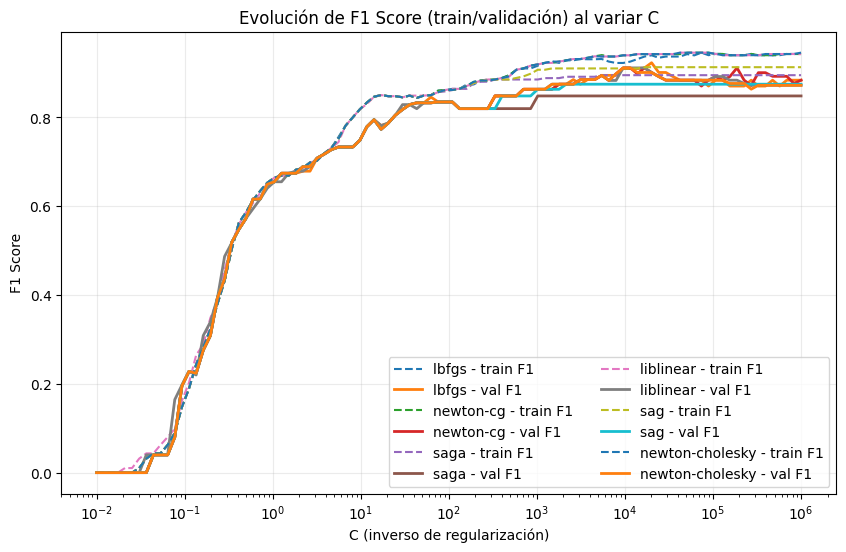

,solver,C,train_f1,val_f1
0,lbfgs,20092.330026,0.939583,0.922863
1,liblinear,9545.484567,0.939583,0.911196
2,newton-cg,9545.484567,0.939583,0.911196
3,newton-cholesky,9545.484567,0.939583,0.911196
4,sag,2154.434690,0.910013,0.874513
5,saga,1023.531022,0.885090,0.848085


Modelos regularizados guardados para 5b: 6
Mejor combinación por CV: solver=lbfgs, C=20092.3, val_F1=0.9229


,modelo,split,accuracy,precision,recall,f1,average_precision,roc_auc,umbral,tn,fp,fn,tp
0,"Polinómica g6 regularizada (lbfgs, C=2.009e+04)",train,0.957746,0.914894,0.955556,0.934783,0.969133,0.987171,NaN,93,4,2,43
1,"Polinómica g6 regularizada (lbfgs, C=2.009e+04)",test,0.944444,0.928571,0.928571,0.928571,0.984642,0.990260,NaN,21,1,1,13


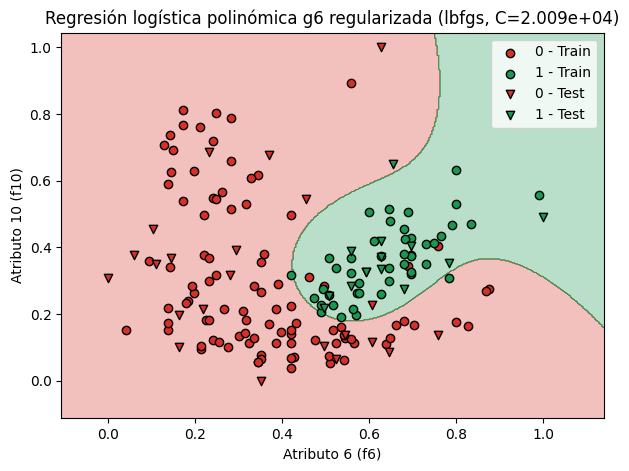

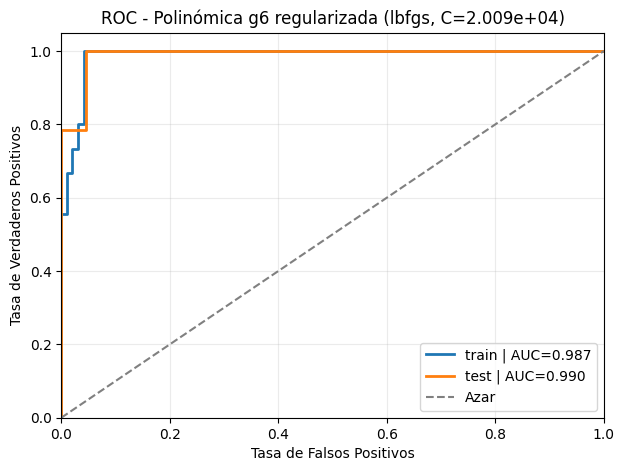

In [7]:
Cs = np.logspace(-2, 6, 100)
solvers_reg = ["lbfgs", "newton-cg", "saga", "liblinear", "sag", "newton-cholesky"]
cv = KFold(n_splits=5, shuffle=True, random_state=28)

grid_reg = GridSearchCV(
    estimator=Pipeline(
        [
            ("poly", PolynomialFeatures(degree=6)),
            ("logreg", LogisticRegression(max_iter=1000, random_state=28)),
        ]
    ),
    param_grid={"logreg__solver": solvers_reg, "logreg__C": Cs},
    scoring="f1",
    cv=cv,
    return_train_score=True,
    n_jobs=-1,
)

grid_reg.fit(X_train, y_train)

cv_results = grid_reg.cv_results_
df_cv = pd.DataFrame(
    {
        "solver": np.array(cv_results["param_logreg__solver"], dtype=str),
        "C": np.array(cv_results["param_logreg__C"], dtype=float),
        "train_f1": cv_results["mean_train_score"],
        "val_f1": cv_results["mean_test_score"],
    }
)




# Las gráficas han sido generadas con inteligencia artficial.

plt.figure(figsize=(10, 6))
for solver in solvers_reg:
    d = df_cv[df_cv["solver"] == solver].sort_values("C")
    if d.empty:
        continue
    plt.semilogx(d["C"], d["train_f1"], linestyle="--", linewidth=1.5, label=f"{solver} - train F1")
    plt.semilogx(d["C"], d["val_f1"], linestyle="-", linewidth=2.0, label=f"{solver} - val F1")

plt.xlabel("C (inverso de regularización)")
plt.ylabel("F1 Score")
plt.title("Evolución de F1 Score (train/validación) al variar C")
plt.grid(alpha=0.25)
plt.legend(loc="best", ncol=2)
plt.show()

# Guardo tambien el mejor C por solver para conservar una versión de cada uno (útil en 5b).
df_mejores_reg_por_solver = (
    df_cv.sort_values(["solver", "val_f1", "C"], ascending=[True, False, True])
    .groupby("solver", as_index=False)
    .first()[["solver", "C", "train_f1", "val_f1"]]
    .sort_values("val_f1", ascending=False)
    .reset_index(drop=True)
)
display(df_mejores_reg_por_solver)

# Tambien reentreno los modelos para después reutilizarlos en el apartado 5b.
modelos_poly_reg_por_solver = {}
mejores_C_reg_por_solver = {}
for _, fila in df_mejores_reg_por_solver.iterrows():
    solver = str(fila["solver"])
    C_solver = float(fila["C"])
    mejores_C_reg_por_solver[solver] = C_solver

    modelo_solver = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=6)),
            ("logreg", LogisticRegression(solver=solver, C=C_solver, max_iter=1000, random_state=28)),
        ]
    )
    modelo_solver.fit(X_train, y_train)
    modelos_poly_reg_por_solver[f"Polinómica g6 reg ({solver}, C={C_solver:.3g})"] = modelo_solver

print(f"Modelos regularizados guardados para 5b: {len(modelos_poly_reg_por_solver)}")

mejor_solver_reg = grid_reg.best_params_["logreg__solver"]
mejor_C = float(grid_reg.best_params_["logreg__C"])

print(f"Mejor combinación por CV: solver={mejor_solver_reg}, C={mejor_C:.6g}, val_F1={grid_reg.best_score_:.4f}")

# GridSearchCV ya reentrena con la mejor combinación usando todo el train, no hace falta reentrenar este.
modelo_poly_reg = grid_reg.best_estimator_

metricas_reg = evaluar_modelo(
    modelo_poly_reg,
    f"Polinómica g6 regularizada ({mejor_solver_reg}, C={mejor_C:.4g})",
    X_train,
    y_train,
    X_test,
    y_test
)
display(metricas_reg)

dibujar_clasificador(
    modelo_poly_reg,
    X_train,
    y_train,
    X_test,
    y_test,
    f"Regresión logística polinómica g6 regularizada ({mejor_solver_reg}, C={mejor_C:.4g})",
)

dibujar_roc_train_test(
    modelo_poly_reg,
    f"Polinómica g6 regularizada ({mejor_solver_reg}, C={mejor_C:.4g})",
    X_train,
    y_train,
    X_test,
    y_test,
)


### Fuentes y enlaces utiles (apartado 4)
- `LogisticRegression` y regularizacion con `C`: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- `GridSearchCV` para seleccionar hiperparametros: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- Guia de validacion cruzada en scikit-learn: https://scikit-learn.org/stable/modules/cross_validation.html


## Conclusiones
El modelo se adapta muy bien.

- Vemos que no hay sobreajuste y tenemos unos resultados en las métricas muy buenos.

- Aunque no tenemos muchos datos de test, vemos que solo tenemos 1 FN y 1 FP. Clasificando bien las otras 34 muestras de test.

---
## 5. Curvas Precisión/Recall y ROC
### a) Comparación en test


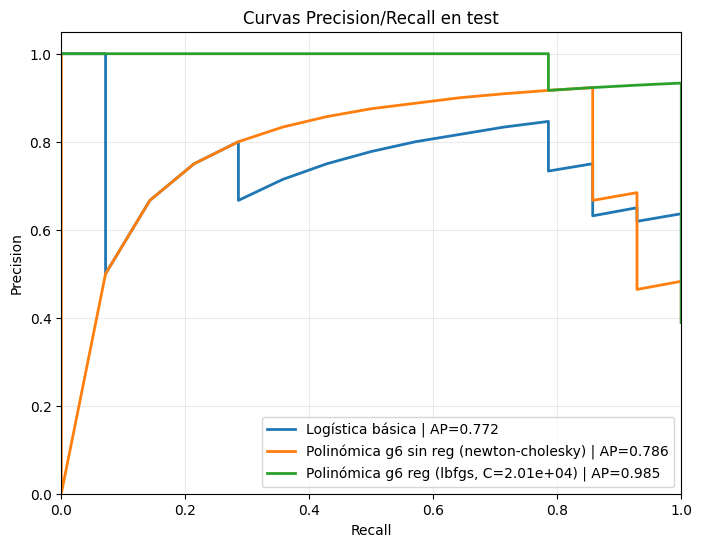

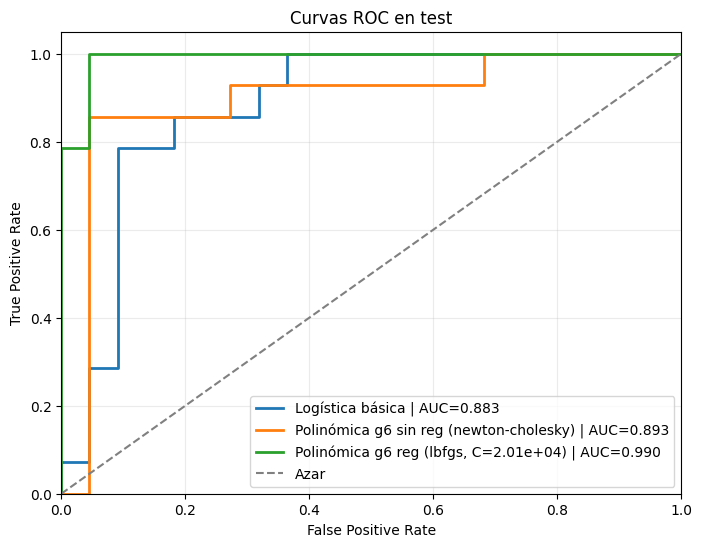

In [8]:
modelos_principales = {
    "Logística básica": logit_basico,
    f"Polinómica g6 sin reg ({mejor_solver_sin_reg})": modelo_poly_sin_reg,
    f"Polinómica g6 reg ({mejor_solver_reg}, C={mejor_C:.3g})": modelo_poly_reg,
}

# Para 5b usamos TODOS los modelos guardados (principales + variantes por solver).
modelos = dict(modelos_principales)
modelos.update(modelos_poly_sin_reg_por_solver)
modelos.update(modelos_poly_reg_por_solver)

probs_test = {nombre: modelo.predict_proba(X_test)[:, 1] for nombre, modelo in modelos_principales.items()}

# Curvas Precision/Recall en una figura conjunta.
plt.figure(figsize=(8, 6))
for nombre, prob in probs_test.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, linewidth=2, label=f"{nombre} | AP={ap:.3f}")


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision/Recall en test")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.show()

# Las gráficas han sido generadas con inteligencia artficial.
# Curvas ROC en una figura conjunta (todos los modelos principales).
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, prob in probs_test.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{nombre} | AUC={auc:.3f}")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curvas ROC en test")
ax.grid(alpha=0.25)
ax.legend(loc="lower right")
plt.show()


### Fuentes y enlaces utiles (apartado 5a)
- `precision_recall_curve`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html
- `roc_curve`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
- `PrecisionRecallDisplay` y `RocCurveDisplay`: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics


## Análisis:
- Vemos claramente como nuestro modelo regularizado gana en nuestra curva, es un modelo bastante bueno.

- En el modelo sin regularizar vemos como sobreajusta, se ve la caída en la curva, cuando antes el entrenamiento tenía un test casi perfecto.

- Logística básica: Como era de esperar, es un modelo qeu subajusta, es muy simple, como hay pocos datos, es capaz de tener un resultado no muy malo.



In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, confusion_matrix

precision_objetivo = 0.90
registros_umbral = []

for nombre, modelo in modelos.items():
    
    # 1. Obtenemos las probabilidades de pertenecer a la clase 1 en el conjunto de test
    y_probs = modelo.predict_proba(X_test)[:, 1]
    
    # 2. Scikit-learn nos calcula todas las combinaciones posibles de umbrales
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
    
    cumplen_precision = precisions[:-1] >= precision_objetivo
    
    if np.any(cumplen_precision):
        # 3. De los que cumplen, buscamos el que nos dé el MAYOR recall
        recalls_cumplen = recalls[:-1][cumplen_precision]
        thresholds_cumplen = thresholds[cumplen_precision]
        
        mejor_idx = np.argmax(recalls_cumplen)
        mejor_threshold = thresholds_cumplen[mejor_idx]
        
        # 4. Clasificamos usando el nuevo umbral manual
        y_pred_ajustado = (y_probs >= mejor_threshold).astype(int)
        
        # Evaluamos
        precision = precision_score(y_test, y_pred_ajustado, zero_division=0)
        recall = recall_score(y_test, y_pred_ajustado, zero_division=0)
        f1 = f1_score(y_test, y_pred_ajustado, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ajustado, labels=[0, 1]).ravel()
        factible = True

    else:
        # Si ningún umbral alcanza el 0.90 de precisión
        mejor_threshold = np.nan
        y_pred_defecto = (y_probs >= 0.5).astype(int)
        precision = precision_score(y_test, y_pred_defecto, zero_division=0)
        recall = recall_score(y_test, y_pred_defecto, zero_division=0)
        f1 = f1_score(y_test, y_pred_defecto, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_defecto, labels=[0, 1]).ravel()
        factible = False

    registros_umbral.append(
        {
            "modelo": nombre,
            "factible": factible,
            "threshold": float(mejor_threshold) if factible else np.nan,
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "predichos_clase1": int(tp + fp),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }
    )
    
df_umbral_manual = pd.DataFrame(registros_umbral).sort_values(
    by=["factible", "recall", "precision"],
    ascending=[False, False, False],
)
display(df_umbral_manual)

,modelo,factible,threshold,precision,recall,f1,predichos_clase1,tn,fp,fn,tp
2,"Polinómica g6 reg (lbfgs, C=2.01e+04)",True,0.273627,0.933333,1.000000,0.965517,15,21,1,0,14
4,Polinómica g6 sin reg (sag),True,0.443398,0.928571,0.928571,0.928571,14,21,1,1,13
10,"Polinómica g6 reg (sag, C=2.15e+03)",True,0.478981,0.928571,0.928571,0.928571,14,21,1,1,13
7,"Polinómica g6 reg (liblinear, C=9.55e+03)",True,0.790797,0.923077,0.857143,0.888889,13,21,1,2,12
9,"Polinómica g6 reg (newton-cholesky, C=9.55e+03)",True,0.799984,0.923077,0.857143,0.888889,13,21,1,2,12
11,"Polinómica g6 reg (saga, C=1.02e+03)",True,0.594119,0.923077,0.857143,0.888889,13,21,1,2,12
6,Polinómica g6 sin reg (saga),True,0.630342,0.916667,0.785714,0.846154,12,21,1,3,11
8,"Polinómica g6 reg (newton-cg, C=9.55e+03)",True,0.822325,0.916667,0.785714,0.846154,12,21,1,3,11
1,Polinómica g6 sin reg (newton-cholesky),True,0.986112,1.000000,0.142857,0.250000,2,22,0,12,2
5,Polinómica g6 sin reg (lbfgs),True,0.985997,1.000000,0.142857,0.250000,2,22,0,12,2


In [11]:
# b) Ajuste de umbral con TunedThresholdClassifierCV para garantizar precision >= 0.90.
# Nota: aquí usamos cv="prefit" para reutilizar los modelos ya ajustados. Si se calibra con test,
# la evaluación sobre ese mismo test queda optimista (sirve para comparación rápida entre modelos).
from sklearn.metrics import make_scorer
from sklearn.model_selection import TunedThresholdClassifierCV


warnings.filterwarnings("ignore", message=".*NewtonCholeskySolver.*")

# Para poder usar TunedThresholdClassifierCV, convierto ese criterio en un "score":
# - si no cumple la precision minima, devuelvo un valor muy malo (-1)
# - si si cumple, devuelvo el recall (asi el tuner maximiza recall)
def recall_si_precision_minima(y_true, y_pred, precision_minima=0.90):
    precision = precision_score(y_true, y_pred)
    if precision < precision_minima:
        return -1.0
    return recall_score(y_true, y_pred)


precision_objetivo = 0.90
scorer_umbral = make_scorer(recall_si_precision_minima, precision_minima=precision_objetivo)
registros_umbral = []

for nombre, modelo in modelos.items():

    tuner = TunedThresholdClassifierCV(
        estimator=modelo,
        scoring=scorer_umbral,
        response_method="predict_proba",
        # Le ponemos que ya está entrenado.
        cv=5,
        refit=True,
    )
    # Entrenamos con datos de train.
    tuner.fit(X_train, y_train)

    y_pred = tuner.predict(X_test)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    registros_umbral.append(
        {
            "modelo": nombre,
            "factible": bool(precision >= precision_objetivo),
            "threshold": float(tuner.best_threshold_),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "predichos_clase1": int(y_pred.sum()),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }
    )


df_umbral = pd.DataFrame(registros_umbral).sort_values(
    by=["factible", "recall", "precision"],
    ascending=[False, False, False],
)
display(df_umbral)


c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,modelo,factible,threshold,precision,recall,f1,predichos_clase1,tn,fp,fn,tp
2,"Polinómica g6 reg (lbfgs, C=2.01e+04)",True,0.252525,0.933333,1.000000,0.965517,15,21,1,0,14
6,Polinómica g6 sin reg (saga),True,0.645999,1.000000,0.785714,0.880000,11,22,0,3,11
10,"Polinómica g6 reg (sag, C=2.15e+03)",True,0.686784,1.000000,0.785714,0.880000,11,22,0,3,11
4,Polinómica g6 sin reg (sag),True,0.636210,0.916667,0.785714,0.846154,12,21,1,3,11
11,"Polinómica g6 reg (saga, C=1.02e+03)",True,0.636131,0.916667,0.785714,0.846154,12,21,1,3,11
7,"Polinómica g6 reg (liblinear, C=9.55e+03)",True,0.898975,0.900000,0.642857,0.750000,10,21,1,5,9
8,"Polinómica g6 reg (newton-cg, C=9.55e+03)",True,0.878773,0.900000,0.642857,0.750000,10,21,1,5,9
9,"Polinómica g6 reg (newton-cholesky, C=9.55e+03)",True,0.888873,0.900000,0.642857,0.750000,10,21,1,5,9
3,Polinómica g6 sin reg (newton-cg),False,0.444444,0.812500,0.928571,0.866667,16,19,3,1,13
1,Polinómica g6 sin reg (newton-cholesky),False,0.555556,0.857143,0.857143,0.857143,14,20,2,2,12


### Fuentes y enlaces utiles (apartado 5b)
- `TunedThresholdClassifierCV`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html
- Guia de ajuste de umbral de decision: https://scikit-learn.org/stable/modules/classification_threshold.html
- `precision_recall_curve` para calcular umbral manual: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html


### Conclusion:

Vemos que al usar el TunedThresholdClassifierCV, en algunos modelos nos empeora el modelo original que hemos entrado ya antes. La mejor solución para este caso resulta calcular de forma iterativa con precision_recall_curve() y pasándole las predicciones de nuestros y los valores de y_test, con eso cogeremos los valores de precisión que superen nuestro 90% deseado y calcularemos los parámetros a mano. De esta manera, nos aseguramos de conseguir los valores que queremos.

## Conclusiones generales

- La regresión lineal se bastante insuficiente, vemos un claro subajuste que se ve claramente incapaz de seperar de manera eficiente las clases de vinos, ya que los datos no son linealmente separables.

- Vemos que al hacer expansión de atributos, este problema se resuelve, pero al hacer una expansión de grado 6, sufrimos sobreajuste, aunque con las 100-500 iteraciones máximas de la regresión, se ve pero no mucho, al aumentar algo las iteraciones y disminuir la tolerancia, vemos un gran sobreajuste en nuestros modelos.

- Al final, vemos que ajustar los modelos mediante el aumento de C (1/λ), ajustando la regularización, conseguimos hacer desaparecer el sobreajuste, dejando modelos más balanceados, como mejor resultado siendo el lbfgs con una C de 8300 aproximadamente.